# LAB-P0: Introducción a los sistemas dinámicos computacionales (Julia)

- **ID de práctica:** LAB-P0-v1.0-julia
- **Capítulo del libro:** Cap. 1 — *An introduction to computational dynamic systems* (Bongers, Gómez y Torres, 2019)
- **Autores:** Dr. Antonio F. Romero Carrasco, Dra. Anelí Bongers
- **Fecha:** 2026-06-19
- **Versión:** 1.0
- **Licencia:** CC BY-SA 4.0 (este notebook) / MIT (el código de `MacroAIComp`)

Modelo de carrera de armamentos de Richardson: un sistema dinámico lineal de
dos ecuaciones que sirve de introducción a los conceptos de estado
estacionario, autovalores y estabilidad antes de abordar modelos
macroeconómicos concretos (IS-LM, Dornbusch, DGE...). Versión en Julia.


> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
>

### 🕹️ GUÍA RÁPIDA PARA DUMMIES - Sistemas Dinámicos
*   **¿Qué estamos haciendo aquí?** Estamos estudiando cómo una variable cambia a lo largo del tiempo usando reglas matemáticas sencillas. Imagina que es el crecimiento de una población o el saldo de tu cuenta bancaria.
*   **Puntos de Equilibrio (Estado Estacionario):** Es el valor donde la variable se queda quieta (no sube ni baja).
*   **Estabilidad:** Si perturbas el sistema (le das un empujón), ¿vuelve al equilibrio (estable) o se dispara al infinito (inestable)?
*   **¡Prueba esto!** Busca donde se definen las matrices o ecuaciones, ejecuta las celdas con `Shift + Enter` y observa cómo las flechas del diagrama de fases te indican hacia dónde viaja el sistema.


In [1]:
# En Google Colab, se instalarían los paquetes necesarios.
# En el entorno local, se asume que las dependencias ya están resueltas.
# using Pkg; Pkg.activate("."); Pkg.instantiate()


In [2]:
using Pkg
Pkg.activate("../..")

using MacroAIComp
using Plots
using LinearAlgebra


  Activating project at `C:\Users\AntonioRC\Desktop\PIE`


## 1. Teoría

El modelo se escribe como un sistema dinámico lineal de dos variables
endógenas (ecs. 1.7-1.11 del libro):

$$
\begin{bmatrix} \Delta x_{1,t} \\ \Delta x_{2,t} \end{bmatrix}
= \underbrace{\begin{bmatrix} -\alpha & \beta \\ \gamma & -\delta \end{bmatrix}}_{A}
\begin{bmatrix} x_{1,t} \\ x_{2,t} \end{bmatrix}
+ \underbrace{\begin{bmatrix} \theta & 0 \\ 0 & \eta \end{bmatrix}}_{B}
\begin{bmatrix} z_{1,t} \\ z_{2,t} \end{bmatrix}
$$

donde $x_{1,t}$ y $x_{2,t}$ son el stock de armamento de los países 1 y 2.
El **estado estacionario** es $\bar{\mathbf{x}} = -A^{-1}B\mathbf{z}$ (ec. 1.14),
y la **estabilidad** depende de los autovalores de $A$: el sistema es
globalmente estable si $|\lambda_i + 1| < 1$ para ambos autovalores, y
presenta un **punto de silla** si solo uno de los dos cumple esa condición
(Apéndice A).


## 2. Calibración — Caso 1: estabilidad global (Tablas 1.1 y 1.2)


In [3]:
params_global = ArmsRaceParams(
    0.50,  # alpha: sensibilidad de Delta x1 a su propio nivel x1
    0.25,  # beta: reacción de Delta x1 al stock de armamento x2
    0.25,  # gamma: reacción de Delta x2 al stock de armamento x1
    0.50,  # delta: sensibilidad de Delta x2 a su propio nivel x2
    1.00,  # theta: impacto de la variable exógena z1 sobre Delta x1
    1.00   # eta: impacto de la variable exógena z2 sobre Delta x2
)
z_initial = [1.0, 1.0]

params_global


ArmsRaceParams(0.5, 0.25, 0.25, 0.5, 1.0, 1.0)

## 3. Resolución: estado estacionario y estabilidad


In [4]:
x_bar = steady_state(params_global, z_initial)
lambdas = eigenvalues(params_global)

println("Estado estacionario (x1_bar, x2_bar) = ", round.(x_bar, digits=2))
println("Autovalores (lambda1, lambda2)        = ", round.(sort(lambdas), digits=2))
println("Moduli |lambda + 1|                   = ", round.(abs.(sort(lambdas) .+ 1.0), digits=2))
println("Punto de silla                        = ", is_saddle_path(params_global))


Estado estacionario (x1_bar, x2_bar) = [4.0, 4.0]
Autovalores (lambda1, lambda2)        = [-0.75, -0.25]
Moduli |lambda + 1|                   = [0.25, 0.75]


Punto de silla                        = false


## 4. Verificación frente al oráculo

Comparamos contra los valores reportados en el libro y reproducidos por el
código MATLAB del Apéndice B (`referencia/m1.m`), recogidos en
`oraculo.md`: estado estacionario $(4, 4)$ y autovalores $(-0.25, -0.75)$.


In [5]:
@assert isapprox(x_bar, [4.0, 4.0]; atol=1e-6)
@assert isapprox(sort(lambdas), [-0.75, -0.25]; atol=1e-6)
println("OK: coincide con el oráculo MATLAB (Apéndice B).")


OK: coincide con el oráculo MATLAB (Apéndice B).


## 5. Análisis de shock (Sección 1.5)

Aumentamos la variable exógena $z_1$ de 1 a 2 y observamos la transición
hacia el nuevo estado estacionario.


Nuevo estado estacionario (x1_bar, x2_bar) = (6.67, 5.33)  (esperado: 6.67, 5.33)


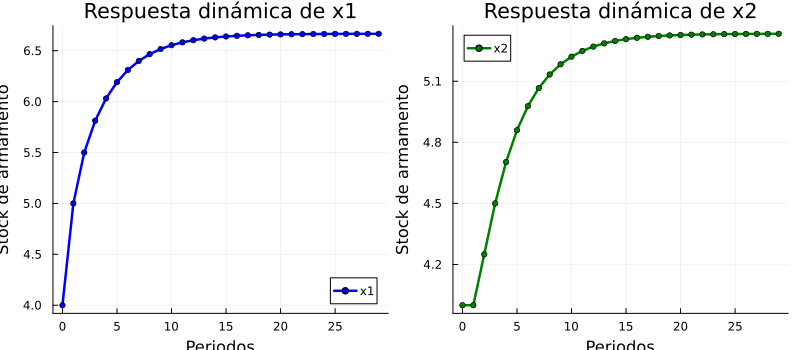

In [6]:
z_final_shock = [2.0, 1.0]
x1_path, x2_path = simulate(params_global, z_initial, z_final_shock, 30, 2)

println("Nuevo estado estacionario (x1_bar, x2_bar) = (", 
        round(x1_path[end], digits=2), ", ", round(x2_path[end], digits=2), 
        ")  (esperado: 6.67, 5.33)")

# Gráfico de respuesta a impulso en Julia usando Plots
t = 0:29
p1 = plot(t, x1_path, label="x1", color=:blue, linewidth=2.5, marker=:circle, markersize=3)
title!("Respuesta dinámica de x1")
xlabel!("Periodos")
ylabel!("Stock de armamento")

p2 = plot(t, x2_path, label="x2", color=:green, linewidth=2.5, marker=:circle, markersize=3)
title!("Respuesta dinámica de x2")
xlabel!("Periodos")
ylabel!("Stock de armamento")

plot(p1, p2, layout=(1,2), size=(800, 350))


## 6. Diagrama de fases (Figura B.1 del Apéndice B)


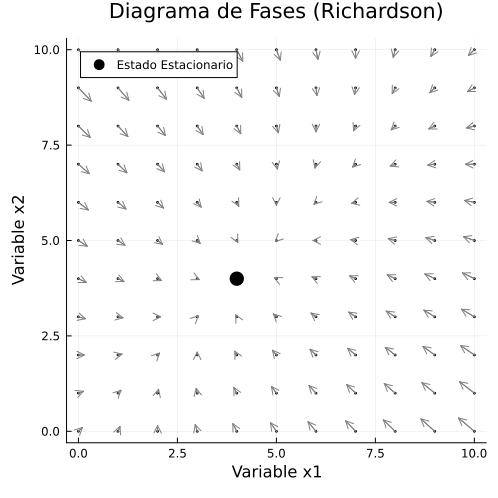

In [7]:
# En Julia, podemos generar el diagrama de fases dibujando las flechas (quiver) en una malla
a, b = coefficient_matrices(params_global)

# Crear la malla de puntos para x1 y x2
x1_vals = range(0, 10, length=11)
x2_vals = range(0, 10, length=11)

x = Float64[]
y = Float64[]
u = Float64[]
v = Float64[]

for xi in x1_vals, yi in x2_vals
    dx = a * [xi, yi] + b * z_initial
    push!(x, xi)
    push!(y, yi)
    push!(u, dx[1])
    push!(v, dx[2])
end

scale = 0.1
arrow_u = u .* scale
arrow_v = v .* scale

plt = plot(x, y, seriestype=:scatter, markersize=1, color=:gray, label="",
           title="Diagrama de Fases (Richardson)", xlabel="Variable x1", ylabel="Variable x2")
quiver!(x, y, quiver=(arrow_u, arrow_v), color=:gray)
scatter!([x_bar[1]], [x_bar[2]], color=:black, markersize=8, label="Estado Estacionario")
plot!(size=(500, 500))


## 7. Análisis de sensibilidad (Sección 1.6.1)

Aumentamos $\alpha$ de 0.50 a 0.70: el país 1 se vuelve más sensible a su
propio stock de armamento, lo que reduce el estado estacionario de ambos
países y rompe la simetría entre ellos.


In [8]:
params_sensitivity = ArmsRaceParams(0.70, 0.25, 0.25, 0.50, 1.00, 1.00)
x_bar_sensitivity = steady_state(params_sensitivity, z_initial)
lambdas_sensitivity = eigenvalues(params_sensitivity)

println("Estado estacionario (x1_bar, x2_bar) = ", round.(x_bar_sensitivity, digits=2), " (esperado: 2.61, 3.30)")
println("Autovalores                          = ", round.(sort(lambdas_sensitivity), digits=2), " (esperado: -0.87, -0.33)")
println("Punto de silla                       = ", is_saddle_path(params_sensitivity), " (esperado: false)")

@assert isapprox(x_bar_sensitivity, [2.61, 3.30]; atol=1e-2)
@assert isapprox(sort(lambdas_sensitivity), [-0.87, -0.33]; atol=1e-2)


Estado estacionario (x1_bar, x2_bar) = [2.61, 3.3] (esperado: 2.61, 3.30)
Autovalores                          = [-0.87, -0.33] (esperado: -0.87, -0.33)
Punto de silla                       = false (esperado: false)


## 8. Punto de silla (Sección 1.6.2)

Con $\beta, \gamma > \alpha, \delta$ (Tabla 1.3) el sistema tiene un
autovalor estable y otro inestable: el estado estacionario es un punto de
silla. La variable $x_1$ se asume "de salto" (forward-looking) y se
reajusta instantáneamente sobre la senda estable ante una perturbación
(ec. 1.39), mientras $x_2$ evoluciona de forma estándar.


Punto de silla = true (esperado: true)


Salto instantáneo de x1 en el periodo del shock = 2.0 (esperado: 2.00)
Nuevo estado estacionario (x1, x2) = (3.33, 2.67)  (esperado: 3.33, 2.67)


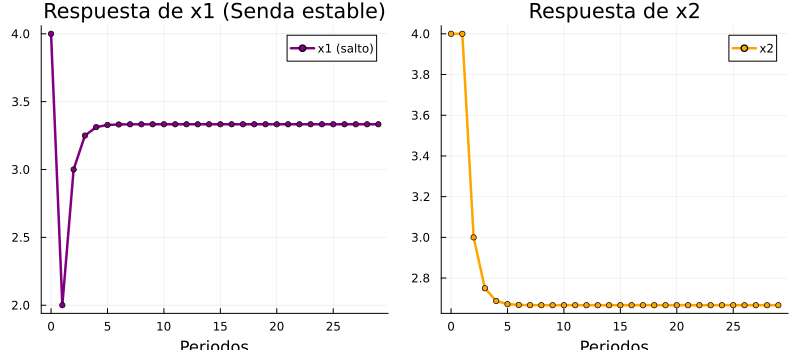

In [9]:
params_saddle = ArmsRaceParams(0.25, 0.50, 0.50, 0.25, 1.00, 1.00)
z_initial_saddle = [-1.0, -1.0]
z_final_saddle = [-0.5, -1.0]

println("Punto de silla = ", is_saddle_path(params_saddle), " (esperado: true)")

x1_saddle, x2_saddle = simulate_saddle_path(
    params_saddle, z_initial_saddle, z_final_saddle, 30, 2, 1
)

println("Salto instantáneo de x1 en el periodo del shock = ", round(x1_saddle[2], digits=2), " (esperado: 2.00)")
println("Nuevo estado estacionario (x1, x2) = (", 
        round(x1_saddle[end], digits=2), ", ", round(x2_saddle[end], digits=2), 
        ")  (esperado: 3.33, 2.67)")

@assert isapprox(x1_saddle[2], 2.0; atol=1e-2)
@assert isapprox([x1_saddle[end], x2_saddle[end]], [3.33, 2.67]; atol=1e-2)

# Graficar la trayectoria del punto de silla
t_axis = 0:29
p_s1 = plot(t_axis, x1_saddle, label="x1 (salto)", color=:purple, linewidth=2.5, marker=:circle, markersize=3)
title!("Respuesta de x1 (Senda estable)")
xlabel!("Periodos")

p_s2 = plot(t_axis, x2_saddle, label="x2", color=:orange, linewidth=2.5, marker=:circle, markersize=3)
title!("Respuesta de x2")
xlabel!("Periodos")

plot(p_s1, p_s2, layout=(1,2), size=(800, 350))


## 9. Simulación alternativa ante variaciones de shock

En lugar de un widget interactivo (que puede requerir configuraciones de Jupyter complejas en Julia), definimos una función modularizada para graficar la transición del sistema para cualquier magnitud de shock sobre $z_1$. Puedes llamar a esta función cambiando el parámetro `z1_final` para ver el efecto.


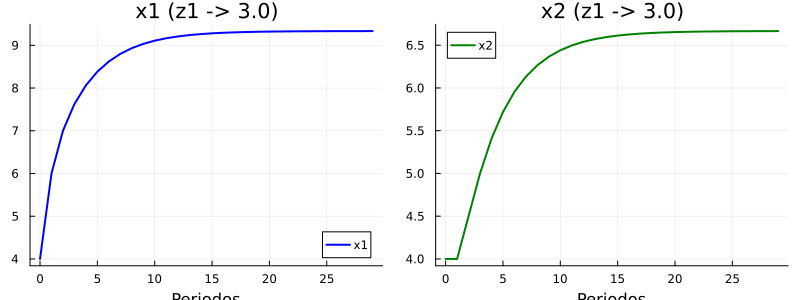

In [10]:
function graficar_shock_z1(z1_final::Float64)
    x1_p, x2_p = simulate(params_global, z_initial, [z1_final, 1.0], 30, 2)
    
    t_ax = 0:29
    p_a = plot(t_ax, x1_p, label="x1", color=:blue, linewidth=2)
    title!("x1 (z1 -> $z1_final)")
    xlabel!("Periodos")
    
    p_b = plot(t_ax, x2_p, label="x2", color=:green, linewidth=2)
    title!("x2 (z1 -> $z1_final)")
    xlabel!("Periodos")
    
    plot(p_a, p_b, layout=(1,2), size=(800, 300))
end

# Ejemplo de ejecución
graficar_shock_z1(3.0)


## 10. Buenas Prácticas Aplicadas en este Laboratorio

Observa que `steady_state()`, `eigenvalues()`, `simulate()` y
`simulate_saddle_path()` están documentadas, tienen restricciones de tipo y viven en
`src/models/ArmsRace.jl` — no en este notebook. La lógica del modelo está separada
de la visualización. Cuando hagas tu ABP, haz lo mismo: funciones reutilizables a `src/`,
el notebook solo para exponer y narrar el análisis.


## 11. Conclusión

El mismo sistema dinámico lineal puede mostrar dos comportamientos
cualitativamente distintos según el valor de sus parámetros: estabilidad
global, donde toda perturbación converge suavemente al nuevo equilibrio, o
un punto de silla, donde una variable debe "saltar" instantáneamente para
mantener la convergencia. Esta distinción —y el procedimiento para
detectarla a partir de los autovalores de $A$— es la base que reutilizaremos
en el resto de prácticas (IS-LM dinámico, Dornbusch, DGE) cuando los
sistemas dejen de ser ejemplos genéricos y representen economías reales.
Los resultados numéricos coinciden exactamente con el oráculo MATLAB del
Apéndice B, lo que valida el port a Julia.
